## Estimating the acceptance rate of fault-tolerant cat state preparation circuits

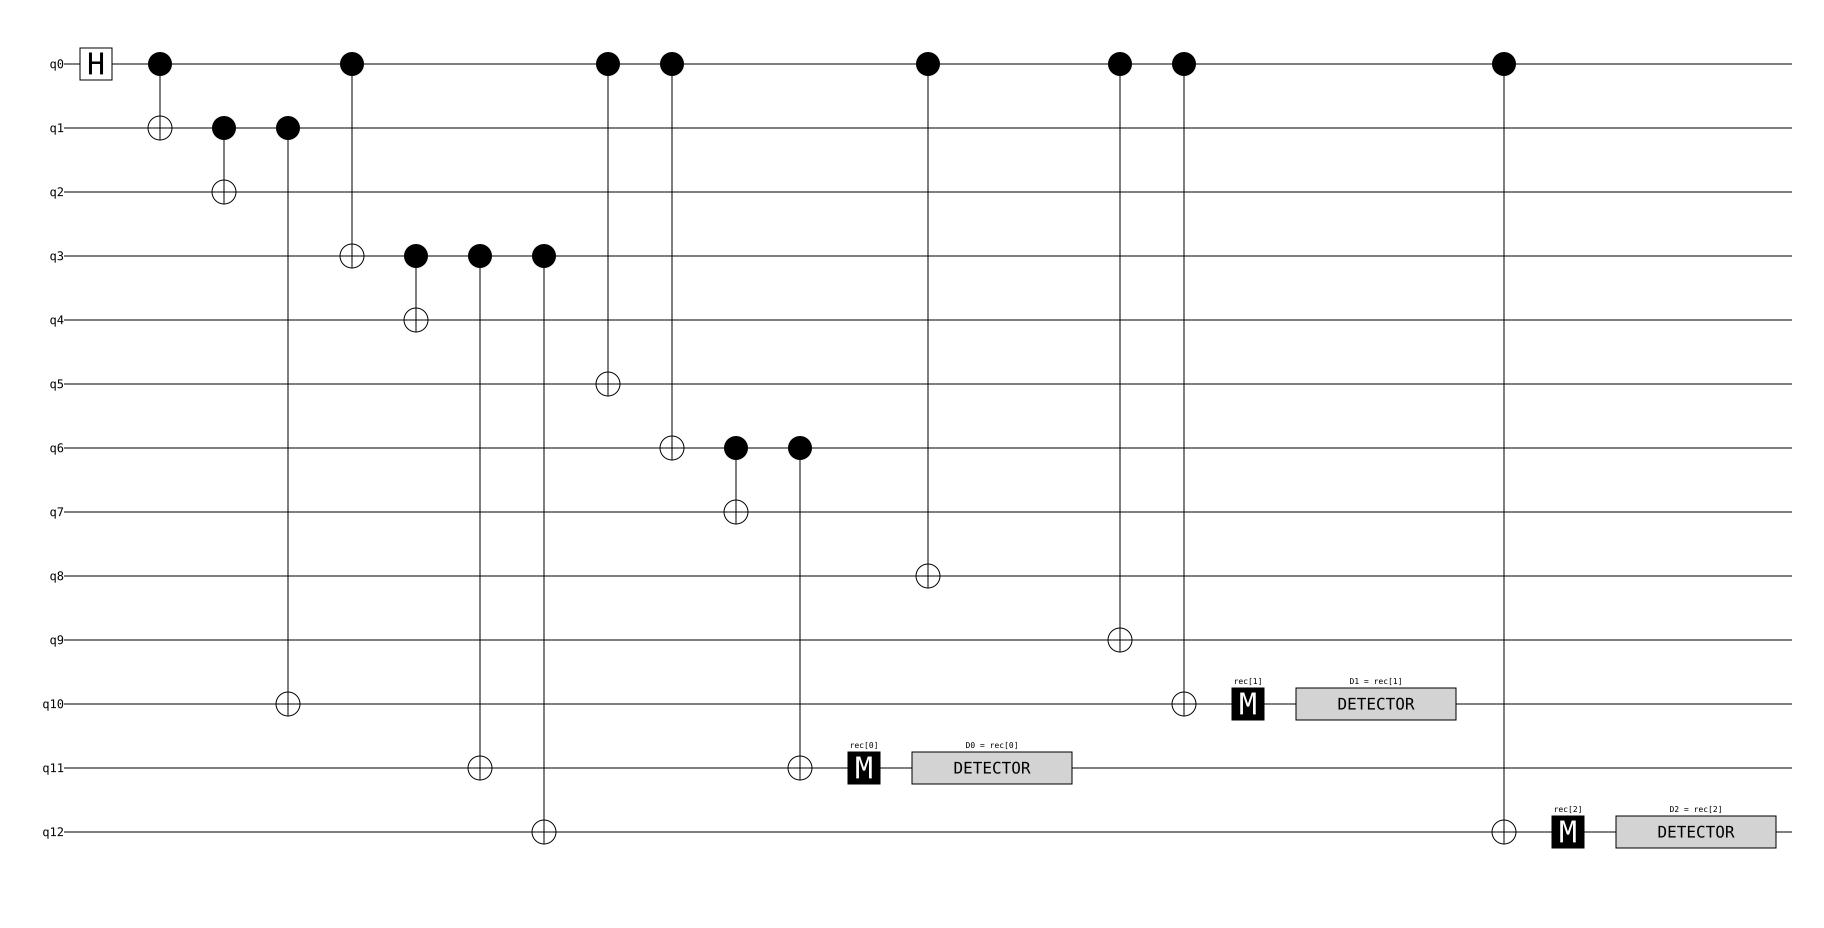

In [1]:
import stim
import numpy as np
from pathlib import Path

############# SET AS NEEDED ###############
num_qubits = 10  # Set
distance = 5
###########################################

t = distance // 2

circuits_folder = Path.cwd().parent.joinpath("spidercat", "circuits")
cat_state_file = circuits_folder.joinpath(f"cat_state_t{t}_n{num_qubits}_p1.stim")
cat_state_text = cat_state_file.read_text()
cat_state_circuit = stim.Circuit(cat_state_text)
cat_state_circuit.diagram('timeline-svg')

We can do a dummy test, sampling from a perfect circuit and observing that none of the flags are raised. Therefore, all samples are accepted.

In [2]:
sampler = cat_state_circuit.compile_sampler()
samples = sampler.sample(4)
print(samples)

[[False False False]
 [False False False]
 [False False False]
 [False False False]]


### Sampling from noisy circuit

We will create a noisy circuit from the perfect circuit shown above, and estimate the acceptance rate from empirical samples.

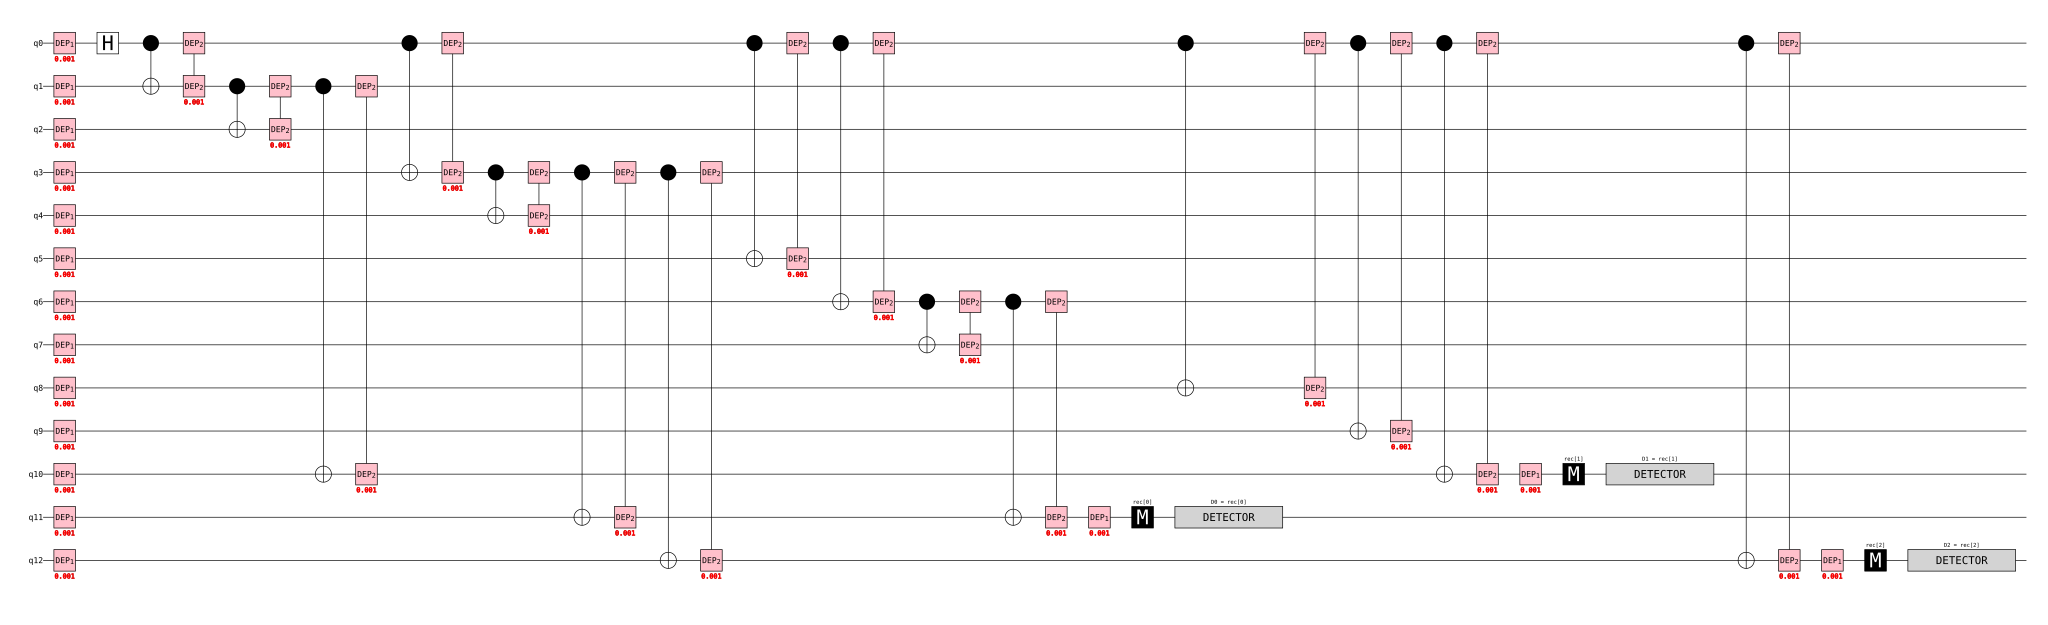

In [9]:
from spidercat.circuit_extraction import make_stim_circ_noisy

p = 0.001
noisy_circuit = make_stim_circ_noisy(cat_state_circuit, p_2=p, p_init=p, p_meas=p)
noisy_circuit.diagram('timeline-svg')

In [10]:
NUM_SAMPLES = 10_000_000

sampler = noisy_circuit.compile_sampler()
samples = sampler.sample(NUM_SAMPLES)
print(samples)

[[False False False]
 [False False False]
 [False False False]
 ...
 [False  True False]
 [False False False]
 [False False False]]


In [11]:
any_flag_raised = np.any(samples, axis=1)
any_flag_raised

array([False, False, False, ...,  True, False, False], shape=(10000000,))

In [12]:
acceptance_rate = (np.sum(~any_flag_raised) / NUM_SAMPLES).tolist()
print(f"The empirical acceptance rate of the size-{num_qubits} CAT state at {t=} is: {acceptance_rate:.3%}")

The empirical acceptance rate of the size-10 CAT state at t=2 is: 98.505%
